In [1]:
import pandas as pd
import numpy as np

In [14]:
#Create simple time-series data
days = 100
data = {"day": np.arange(days), "temperature": np.random.normal(30, 2, days)}
df = pd.DataFrame(data)
df.head()

,day,temperature
0,0,31.175667
1,1,27.320052
2,2,31.788886
3,3,30.280327
4,4,28.498998


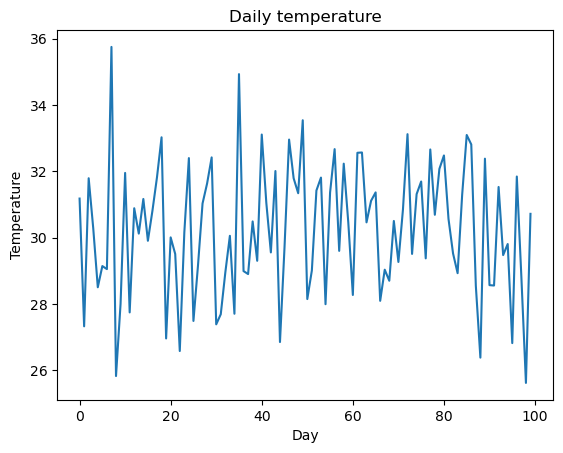

In [19]:
###Plotting the data
import matplotlib.pyplot as plt
plt.plot(df["day"], df["temperature"])
plt.xlabel("Day")
plt.ylabel("Temperature")
plt.title("Daily temperature")
plt.show()

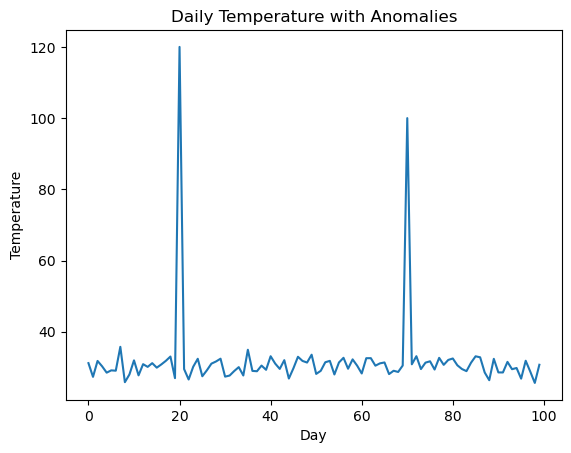

In [25]:
#Inject anomalies and re-plot
df.loc[20, "temperature"] = 120
df.loc[70, "temperature"] = 100


plt.plot(df["day"], df["temperature"])
plt.xlabel("Day")
plt.ylabel("Temperature")
plt.title("Daily Temperature with Anomalies")
plt.show()

#Anomaly = something that does not follow normal behavior

In [29]:
#Prepare data for ML 

from sklearn.preprocessing import StandardScaler
X = df[["temperature"]]
X_scaled = StandardScaler().fit_transform(X)
print(X_scaled)

[[-5.81285758e-02]
 [-3.95412633e-01]
 [-4.48503724e-03]
 [-1.36451770e-01]
 [-2.92280058e-01]
 [-2.36331719e-01]
 [-2.44345528e-01]
 [ 3.42162928e-01]
 [-5.26638426e-01]
 [-3.36051659e-01]
 [ 9.53033264e-03]
 [-3.58673924e-01]
 [-8.37062137e-02]
 [-1.50602843e-01]
 [-5.92542020e-02]
 [-1.69560715e-01]
 [-9.00605524e-02]
 [-1.56095927e-03]
 [ 1.03577538e-01]
 [-4.27423201e-01]
 [ 7.71210518e+00]
 [-2.04501732e-01]
 [-4.60597348e-01]
 [-1.47372025e-01]
 [ 4.87029084e-02]
 [-3.81202805e-01]
 [-2.34670813e-01]
 [-7.10830496e-02]
 [-1.82380590e-02]
 [ 5.05234008e-02]
 [-3.90170316e-01]
 [-3.63523428e-01]
 [-2.53269591e-01]
 [-1.56445111e-01]
 [-3.62217830e-01]
 [ 2.70370523e-01]
 [-2.49622132e-01]
 [-2.57445349e-01]
 [-1.18513256e-01]
 [-2.22406329e-01]
 [ 1.10850952e-01]
 [-6.93100545e-02]
 [-2.00292422e-01]
 [ 1.45584121e-02]
 [-4.36857919e-01]
 [-1.85877664e-01]
 [ 9.75828776e-02]
 [-4.54003020e-03]
 [-4.40424055e-02]
 [ 1.48611446e-01]
 [-3.23391132e-01]
 [-2.47962869e-01]
 [-3.6884287

In [30]:
#ML Model: Using Isolation Forest
from sklearn.ensemble import IsolationForest
model = IsolationForest(contamination=0.02, random_state=42)
df["anomaly"] = model.fit_predict(X_scaled)
df["anomaly"] = df["anomaly"].map({1: 0, -1: 1})
df.head()

,day,temperature,anomaly
0,0,31.175667,0
1,1,27.320052,0
2,2,31.788886,0
3,3,30.280327,0
4,4,28.498998,0


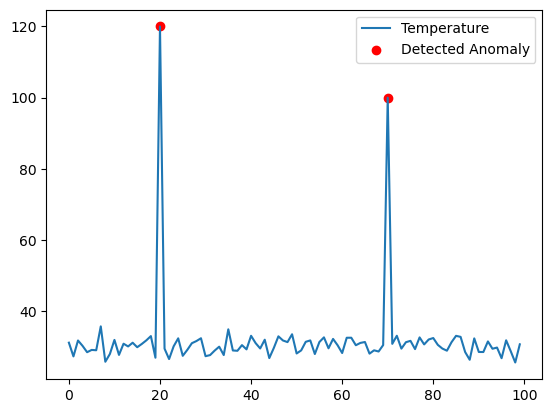

In [31]:
#Visualize ML output

plt.plot(df["day"], df["temperature"], label="Temperature")
plt.scatter(
    df[df["anomaly"] == 1]["day"],
    df[df["anomaly"] == 1]["temperature"],
    color="red",
    label="Detected Anomaly"
)
plt.legend()
plt.show()